# Import Library

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import random_split
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Device Check

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


# Dataset Information

In [5]:
dataset_path = "dataset"

classes = os.listdir(dataset_path)

print("Classes:")
print(classes)

Classes:
['fresh', 'rotten']


# Class Distribution

In [6]:
class_counts = {}

for cls in classes:

    class_path = os.path.join(
        dataset_path,
        cls
    )

    count = len(os.listdir(class_path))

    class_counts[cls] = count

df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Count"]
)

print(df)

    Class  Count
0   fresh  11200
1  rotten  12419


## Visualisasi

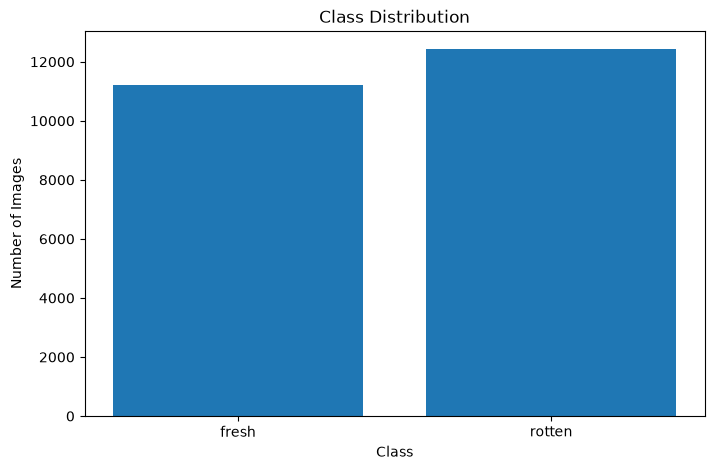

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Class"],
    df["Count"]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

# Sample Images

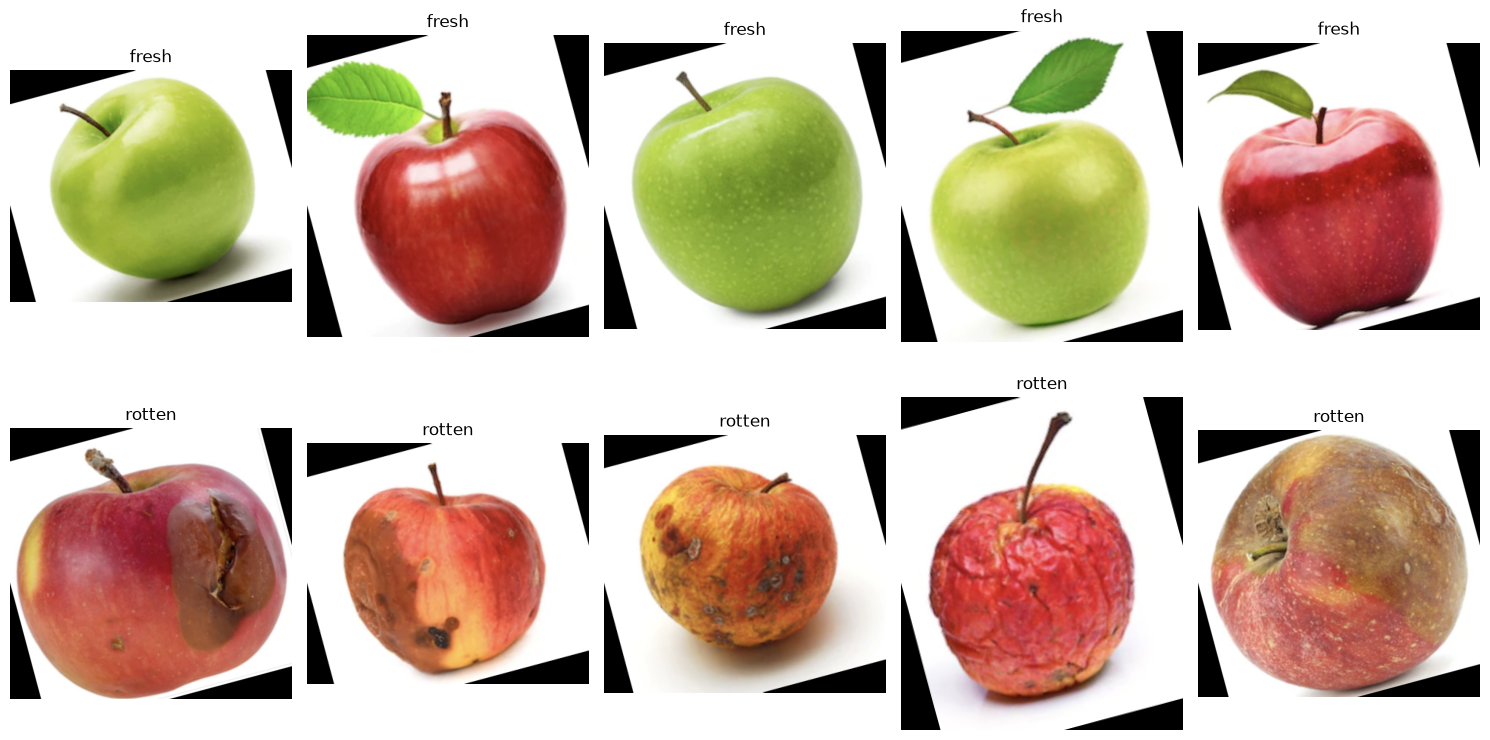

In [8]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15,8)
)

for row, cls in enumerate(classes):

    class_path = os.path.join(
        dataset_path,
        cls
    )

    images = os.listdir(class_path)[:5]

    for col, img_name in enumerate(images):

        img_path = os.path.join(
            class_path,
            img_name
        )

        img = Image.open(img_path)

        axes[row,col].imshow(img)
        axes[row,col].set_title(cls)
        axes[row,col].axis("off")

plt.tight_layout()
plt.show()

# Resolution Analysis

In [9]:
widths = []
heights = []

for cls in classes:

    class_path = os.path.join(
        dataset_path,
        cls
    )

    for img_name in os.listdir(class_path):

        try:

            img = Image.open(
                os.path.join(
                    class_path,
                    img_name
                )
            )

            w,h = img.size

            widths.append(w)
            heights.append(h)

        except:
            pass

# Images Transform

In [10]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

# Load Dataset

In [11]:
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

## Class mapping

In [12]:
print(dataset.class_to_idx)

{'fresh': 0, 'rotten': 1}


# Data Splitting

In [13]:
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

# Data Loader

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Load RestNet50

In [15]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\ROG/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


# Freeze Layers

In [16]:
for param in model.parameters():
    param.requires_grad = False

# Replace Final Layers

In [17]:
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features,256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256,1),
    nn.Sigmoid()
)

# Move model to device

In [18]:
model = model.to(device)

# Loss & Optimizer

In [19]:
criterion = nn.BCELoss()
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.0001
)

# Training Loop

In [21]:
epochs = 25
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs,labels)
            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/25] Train Loss: 0.1530 Val Loss: 0.1135
Epoch [2/25] Train Loss: 0.1333 Val Loss: 0.0998
Epoch [3/25] Train Loss: 0.1230 Val Loss: 0.0951
Epoch [4/25] Train Loss: 0.1143 Val Loss: 0.0864
Epoch [5/25] Train Loss: 0.1092 Val Loss: 0.0841
Epoch [6/25] Train Loss: 0.1062 Val Loss: 0.0760
Epoch [7/25] Train Loss: 0.1003 Val Loss: 0.0782
Epoch [8/25] Train Loss: 0.0991 Val Loss: 0.0807
Epoch [9/25] Train Loss: 0.0921 Val Loss: 0.0701
Epoch [10/25] Train Loss: 0.0952 Val Loss: 0.0684
Epoch [11/25] Train Loss: 0.0868 Val Loss: 0.0600
Epoch [12/25] Train Loss: 0.0870 Val Loss: 0.0594
Epoch [13/25] Train Loss: 0.0856 Val Loss: 0.0611
Epoch [14/25] Train Loss: 0.0776 Val Loss: 0.0566
Epoch [15/25] Train Loss: 0.0772 Val Loss: 0.0555
Epoch [16/25] Train Loss: 0.0781 Val Loss: 0.0586
Epoch [17/25] Train Loss: 0.0772 Val Loss: 0.0545
Epoch [18/25] Train Loss: 0.0747 Val Loss: 0.0543
Epoch [19/25] Train Loss: 0.0721 Val Loss: 0.0570
Epoch [20/25] Train Loss: 0.0721 Val Loss: 0.0514
Epoch [21

# Loss Curve

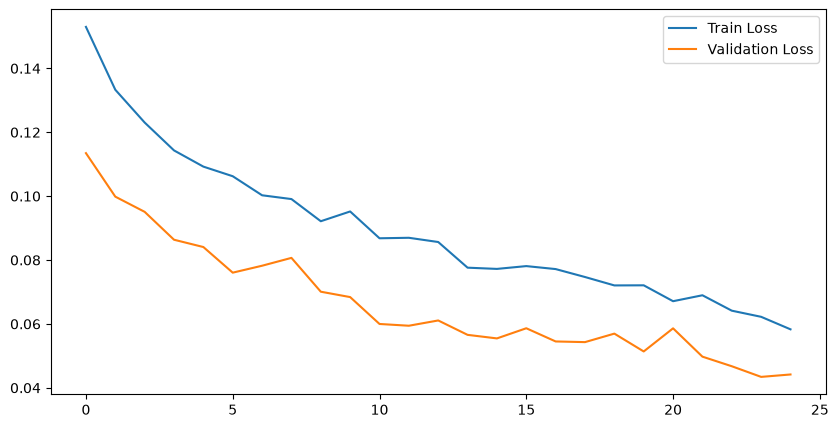

In [22]:
plt.figure(figsize=(10,5))
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.legend()
plt.show()

# Evaluation

In [23]:
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = (outputs > 0.5).int()
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().flatten()
    )

# Confusion Matrix

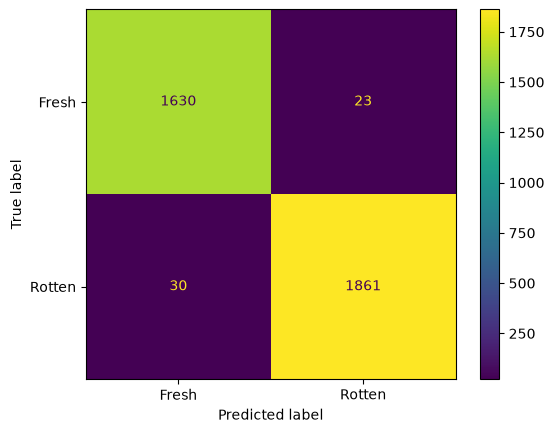

In [24]:
cm = confusion_matrix(y_true,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Fresh","Rotten"])
disp.plot()
plt.show()

# Classification Report

In [25]:
print(classification_report(
        y_true,
        y_pred,
        target_names=[
            "Fresh",
            "Rotten"
        ]
    )
)

              precision    recall  f1-score   support

       Fresh       0.98      0.99      0.98      1653
      Rotten       0.99      0.98      0.99      1891

    accuracy                           0.99      3544
   macro avg       0.98      0.99      0.98      3544
weighted avg       0.99      0.99      0.99      3544



# Save Model

In [26]:
torch.save(model.state_dict(),"save_n_serve_resnet50.pth")

# Image Prediction

In [27]:
image_path = "sample.jpg"
img = Image.open(image_path).convert("RGB")
img = transform(img)
img = img.unsqueeze(0)
img = img.to(device)
model.eval()
with torch.no_grad():
    output = model(img)
    prob = output.item()
if prob > 0.5:
    print("Rotten")
    print("Confidence:", prob)
else:
    print("Fresh")
    print("Confidence:", 1-prob)

Rotten
Confidence: 0.6892517805099487
